<a href="https://colab.research.google.com/github/gestionymetrologia-lang/ModelosAnaliticosUnicafam202607/blob/main/Taller_julio_22_(Criminalidad)%2C_Manuel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Paso 1. Importar todas las librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
# Paso 2. Importar el dataset

dataset=pd.read_excel("/content/sample_data/crime_data.xlsx")

In [5]:
# Paso 3. Seleccionar las columnas para determinar el cluster

# En el archivo, las columnas están organizadas así:
# 0: nombre del estado
# 1: Murder
# 2: Assault
# 3: UrbanPop
# 4: Rape

X = dataset.iloc[:, [1, 2, 3, 4]].values

print(X)
print(X.shape)

[[ 13.2 236.   58.   21.2]
 [ 10.  263.   48.   44.5]
 [  8.1 294.   80.   31. ]
 [  8.8 190.   50.   19.5]
 [  9.  276.   91.   40.6]
 [  7.9 204.   78.   38.7]
 [  3.3 110.   77.   11.1]
 [  5.9 238.   72.   15.8]
 [ 15.4 335.   80.   31.9]
 [ 17.4 211.   60.   25.8]
 [  5.3  46.   83.   20.2]
 [  2.6 120.   54.   14.2]
 [ 10.4 249.   83.   24. ]
 [  7.2 113.   65.   21. ]
 [  2.2  56.   57.   11.3]
 [  6.  115.   66.   18. ]
 [  9.7 109.   52.   16.3]
 [ 15.4 249.   66.   22.2]
 [  2.1  83.   51.    7.8]
 [ 11.3 300.   67.   27.8]
 [  4.4 149.   85.   16.3]
 [ 12.1 255.   74.   35.1]
 [  2.7  72.   66.   14.9]
 [ 16.1 259.   44.   17.1]
 [  9.  178.   70.   28.2]
 [  6.  109.   53.   16.4]
 [  4.3 102.   62.   16.5]
 [ 12.2 252.   81.   46. ]
 [  2.1  57.   56.    9.5]
 [  7.4 159.   89.   18.8]
 [ 11.4 285.   70.   32.1]
 [ 11.1 254.   86.   26.1]
 [ 13.  337.   45.   16.1]
 [  0.8  45.   44.    7.3]
 [  7.3 120.   75.   21.4]
 [  6.6 151.   68.   20. ]
 [  4.9 159.   67.   29.3]
 

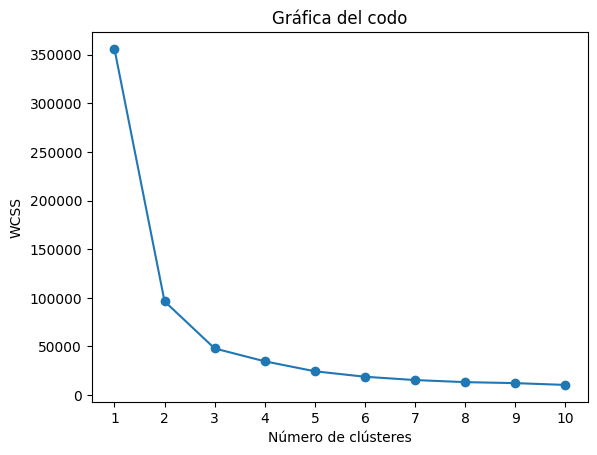

In [7]:
# Paso 4. Determinar el número adecuado de clústeres

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Gráfica del codo

plt.plot(range(1, 11), wcss, marker="o")
plt.title("Gráfica del codo")
plt.xlabel("Número de clústeres")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.show()

In [8]:
# Paso 5. Entrenar el modelo con 4 clústeres

kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

print(y_kmeans)

[1 1 1 2 1 2 3 1 1 2 0 3 1 3 0 3 3 1 0 1 2 1 0 1 2 3 3 1 0 2 1 1 1 0 3 2 2
 3 2 1 0 2 2 3 0 2 2 0 0 2]


In [9]:
# Paso 6. Agregar el clúster asignado a cada estado

dataset["Cluster"] = y_kmeans

dataset

,Unnamed: 0,Murder,Assault,UrbanPop,Rape,Cluster
0,Alabama,13.2,236,58,21.2,1
1,Alaska,10.0,263,48,44.5,1
2,Arizona,8.1,294,80,31.0,1
3,Arkansas,8.8,190,50,19.5,2
4,California,9.0,276,91,40.6,1
5,Colorado,7.9,204,78,38.7,2
6,Connecticut,3.3,110,77,11.1,3
7,Delaware,5.9,238,72,15.8,1
8,Florida,15.4,335,80,31.9,1
9,Georgia,17.4,211,60,25.8,2


In [10]:
# Paso 7. Organizar los estados por clúster

dataset = dataset.rename(
    columns={"Unnamed: 0": "State"}
)

dataset_ordenado = dataset.sort_values(
    by="Cluster"
)

dataset_ordenado[
    ["State", "Murder", "Assault", "UrbanPop", "Rape", "Cluster"]
]

,State,Murder,Assault,UrbanPop,Rape,Cluster
14,Iowa,2.2,56,57,11.3,0
10,Hawaii,5.3,46,83,20.2,0
22,Minnesota,2.7,72,66,14.9,0
18,Maine,2.1,83,51,7.8,0
28,New Hampshire,2.1,57,56,9.5,0
44,Vermont,2.2,48,32,11.2,0
47,West Virginia,5.7,81,39,9.3,0
33,North Dakota,0.8,45,44,7.3,0
40,South Dakota,3.8,86,45,12.8,0
48,Wisconsin,2.6,53,66,10.8,0


In [11]:
# Paso 8. Promedios de criminalidad por clúster

resumen_clusters = dataset.groupby("Cluster")[
    ["Murder", "Assault", "UrbanPop", "Rape"]
].mean()

resumen_clusters

,Murder,Assault,UrbanPop,Rape
Cluster,,,,
0,2.950000,62.700000,53.900000,11.510000
1,11.812500,272.562500,68.312500,28.375000
2,8.214286,173.285714,70.642857,22.842857
3,5.590000,112.400000,65.600000,17.270000


In [12]:
# Paso 9. Clasificar los clústeres por nivel de criminalidad

resumen_clusters["Indice_criminalidad"] = resumen_clusters[
    ["Murder", "Assault", "Rape"]
].mean(axis=1)

resumen_clusters = resumen_clusters.sort_values(
    by="Indice_criminalidad"
)

resumen_clusters

,Murder,Assault,UrbanPop,Rape,Indice_criminalidad
Cluster,,,,,
0,2.950000,62.700000,53.900000,11.510000,25.720000
3,5.590000,112.400000,65.600000,17.270000,45.086667
2,8.214286,173.285714,70.642857,22.842857,68.114286
1,11.812500,272.562500,68.312500,28.375000,104.250000


In [13]:
# Paso 10. Asignar nivel de prioridad a cada clúster

orden_clusters = resumen_clusters.index.tolist()

prioridades = {
    orden_clusters[0]: "Baja",
    orden_clusters[1]: "Media",
    orden_clusters[2]: "Media",
    orden_clusters[3]: "Alta"
}

dataset["Prioridad"] = dataset["Cluster"].map(prioridades)

dataset[
    ["State", "Murder", "Assault", "UrbanPop", "Rape", "Cluster", "Prioridad"]
].sort_values(by="Cluster")

,State,Murder,Assault,UrbanPop,Rape,Cluster,Prioridad
14,Iowa,2.2,56,57,11.3,0,Baja
10,Hawaii,5.3,46,83,20.2,0,Baja
22,Minnesota,2.7,72,66,14.9,0,Baja
18,Maine,2.1,83,51,7.8,0,Baja
28,New Hampshire,2.1,57,56,9.5,0,Baja
44,Vermont,2.2,48,32,11.2,0,Baja
47,West Virginia,5.7,81,39,9.3,0,Baja
33,North Dakota,0.8,45,44,7.3,0,Baja
40,South Dakota,3.8,86,45,12.8,0,Baja
48,Wisconsin,2.6,53,66,10.8,0,Baja


In [14]:
# Paso 11. Mostrar los estados que requieren mayor capacidad de atención

estados_alta_prioridad = dataset[
    dataset["Prioridad"] == "Alta"
]

estados_alta_prioridad[
    ["State", "Murder", "Assault", "UrbanPop", "Rape", "Cluster", "Prioridad"]
]

,State,Murder,Assault,UrbanPop,Rape,Cluster,Prioridad
0,Alabama,13.2,236,58,21.2,1,Alta
1,Alaska,10.0,263,48,44.5,1,Alta
2,Arizona,8.1,294,80,31.0,1,Alta
4,California,9.0,276,91,40.6,1,Alta
7,Delaware,5.9,238,72,15.8,1,Alta
8,Florida,15.4,335,80,31.9,1,Alta
12,Illinois,10.4,249,83,24.0,1,Alta
17,Louisiana,15.4,249,66,22.2,1,Alta
19,Maryland,11.3,300,67,27.8,1,Alta
21,Michigan,12.1,255,74,35.1,1,Alta


In [15]:
# Paso 12. Asignar el tipo de personal a cada estado

tipos_personal = {
    "Alta": "Policías especializados",
    "Media": "Policías de a pie",
    "Baja": "Cadetes"
}

dataset["Tipo_personal"] = dataset["Prioridad"].map(tipos_personal)

dataset[
    ["State", "Cluster", "Prioridad", "Tipo_personal"]
].sort_values(by="Prioridad")

,State,Cluster,Prioridad,Tipo_personal
0,Alabama,1,Alta,Policías especializados
32,North Carolina,1,Alta,Policías especializados
31,New York,1,Alta,Policías especializados
30,New Mexico,1,Alta,Policías especializados
27,Nevada,1,Alta,Policías especializados
23,Mississippi,1,Alta,Policías especializados
21,Michigan,1,Alta,Policías especializados
39,South Carolina,1,Alta,Policías especializados
19,Maryland,1,Alta,Policías especializados
12,Illinois,1,Alta,Policías especializados


In [16]:
# Paso 13. Contar estados por nivel de prioridad

cantidad_estados = dataset["Prioridad"].value_counts()

cantidad_estados

print("Estados de prioridad alta:",
      cantidad_estados["Alta"])

print("Estados de prioridad media:",
      cantidad_estados["Media"])

print("Estados de prioridad baja:",
      cantidad_estados["Baja"])

Estados de prioridad alta: 16
Estados de prioridad media: 24
Estados de prioridad baja: 10


In [17]:
# Paso 14. Distribuir el personal disponible

recursos_totales = {
    "Alta": 300,
    "Media": 500,
    "Baja": 150
}

dataset["Personal_asignado"] = 0

for prioridad in ["Alta", "Media", "Baja"]:

    estados = dataset[
        dataset["Prioridad"] == prioridad
    ].index.tolist()

    cantidad = len(estados)
    total_personal = recursos_totales[prioridad]

    personal_base = total_personal // cantidad
    sobrantes = total_personal % cantidad

    # Asignación básica a todos los estados
    for estado in estados:
        dataset.loc[estado, "Personal_asignado"] = personal_base

    # Distribuir los funcionarios sobrantes
    for estado in estados[:sobrantes]:
        dataset.loc[estado, "Personal_asignado"] += 1

dataset[
    [
        "State",
        "Prioridad",
        "Tipo_personal",
        "Personal_asignado"
    ]
].sort_values(by="Prioridad")

,State,Prioridad,Tipo_personal,Personal_asignado
0,Alabama,Alta,Policías especializados,19
32,North Carolina,Alta,Policías especializados,18
31,New York,Alta,Policías especializados,18
30,New Mexico,Alta,Policías especializados,18
27,Nevada,Alta,Policías especializados,19
23,Mississippi,Alta,Policías especializados,19
21,Michigan,Alta,Policías especializados,19
39,South Carolina,Alta,Policías especializados,18
19,Maryland,Alta,Policías especializados,19
12,Illinois,Alta,Policías especializados,19


In [20]:
# Paso 15. Verificar el total de personal asignado

verificacion = dataset.groupby(
    ["Prioridad", "Tipo_personal"]
)["Personal_asignado"].sum()

verificacion

,,Personal_asignado
Prioridad,Tipo_personal,
Alta,Policías especializados,300
Baja,Cadetes,150
Media,Policías de a pie,500


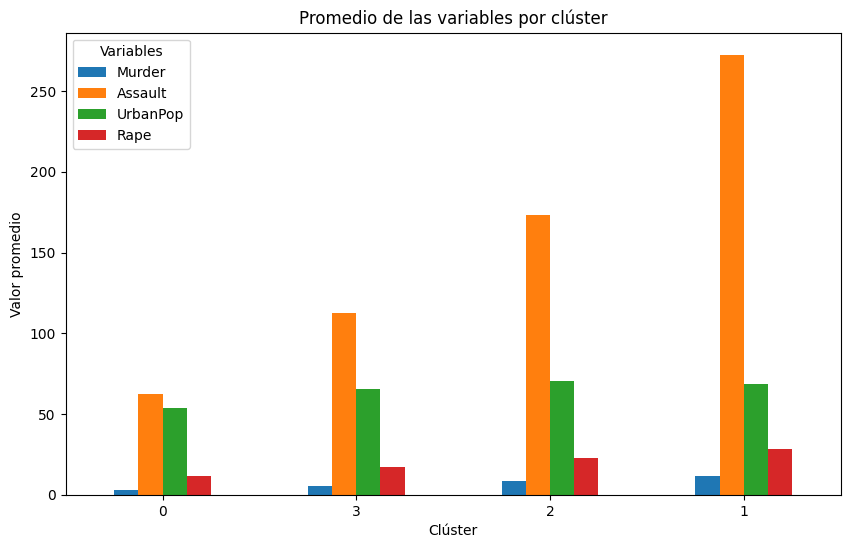

In [21]:
# Paso 16. Visualizar las características de cada clúster

resumen_clusters[
    ["Murder", "Assault", "UrbanPop", "Rape"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Promedio de las variables por clúster")
plt.xlabel("Clúster")
plt.ylabel("Valor promedio")
plt.xticks(rotation=0)
plt.legend(title="Variables")
plt.show()

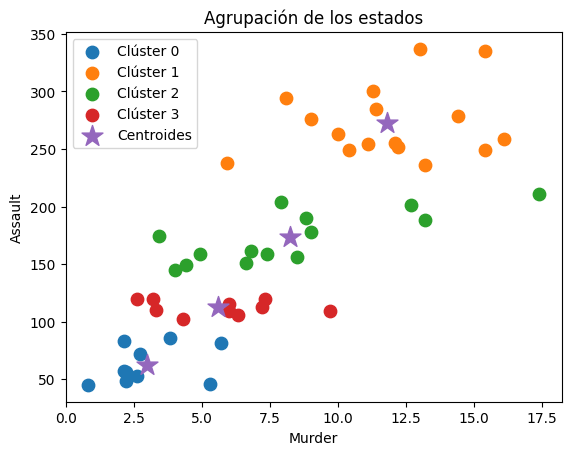

In [22]:
# Paso 17. Visualizar los clústeres

for cluster in range(4):
    plt.scatter(
        X[y_kmeans == cluster, 0],
        X[y_kmeans == cluster, 1],
        s=80,
        label="Clúster " + str(cluster)
    )

# Mostrar los centroides
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    marker="*",
    label="Centroides"
)

plt.title("Agrupación de los estados")
plt.xlabel("Murder")
plt.ylabel("Assault")
plt.legend()
plt.show()

In [23]:
# Paso 18. Exportar los resultados

dataset.to_excel(
    "Resultados_criminalidad.xlsx",
    index=False
)

dataset.to_csv(
    "Resultados_criminalidad.csv",
    index=False
)

print("Archivos guardados correctamente")

Archivos guardados correctamente


In [24]:
from google.colab import files

files.download("Resultados_criminalidad.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# Paso 20. Crear el resumen final de los clústeres

resumen_final = dataset.groupby(
    ["Cluster", "Prioridad", "Tipo_personal"]
).agg(
    Cantidad_estados=("State", "count"),
    Estados=("State", lambda x: ", ".join(x)),
    Promedio_Murder=("Murder", "mean"),
    Promedio_Assault=("Assault", "mean"),
    Promedio_UrbanPop=("UrbanPop", "mean"),
    Promedio_Rape=("Rape", "mean"),
    Personal_total=("Personal_asignado", "sum")
).reset_index()

resumen_final = resumen_final.round(2)

resumen_final

,Cluster,Prioridad,Tipo_personal,Cantidad_estados,Estados,Promedio_Murder,Promedio_Assault,Promedio_UrbanPop,Promedio_Rape,Personal_total
0,0,Baja,Cadetes,10,"Hawaii, Iowa, Maine, Minnesota, New Hampshire,...",2.95,62.70,53.90,11.51,150
1,1,Alta,Policías especializados,16,"Alabama, Alaska, Arizona, California, Delaware...",11.81,272.56,68.31,28.38,300
2,2,Media,Policías de a pie,14,"Arkansas, Colorado, Georgia, Massachusetts, Mi...",8.21,173.29,70.64,22.84,291
3,3,Media,Policías de a pie,10,"Connecticut, Idaho, Indiana, Kansas, Kentucky,...",5.59,112.40,65.60,17.27,209


In [26]:
# Paso 21. Guardar los resultados completos en un archivo de Excel

with pd.ExcelWriter("Informe_criminalidad.xlsx") as archivo:

    dataset.to_excel(
        archivo,
        sheet_name="Resultados por estado",
        index=False
    )

    resumen_final.to_excel(
        archivo,
        sheet_name="Resumen de clusters",
        index=False
    )

print("Informe guardado correctamente")

Informe guardado correctamente


In [27]:
from google.colab import files

files.download("Informe_criminalidad.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# Paso 22. Interpretar los resultados obtenidos

for prioridad in ["Alta", "Media", "Baja"]:

    grupo = dataset[
        dataset["Prioridad"] == prioridad
    ]

    print("\nPRIORIDAD:", prioridad)
    print("Cantidad de estados:", len(grupo))
    print("Estados:", ", ".join(grupo["State"]))
    print("Tipo de personal:", grupo["Tipo_personal"].iloc[0])
    print("Personal total asignado:", grupo["Personal_asignado"].sum())


PRIORIDAD: Alta
Cantidad de estados: 16
Estados: Alabama, Alaska, Arizona, California, Delaware, Florida, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina
Tipo de personal: Policías especializados
Personal total asignado: 300

PRIORIDAD: Media
Cantidad de estados: 24
Estados: Arkansas, Colorado, Connecticut, Georgia, Idaho, Indiana, Kansas, Kentucky, Massachusetts, Missouri, Montana, Nebraska, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Tennessee, Texas, Utah, Virginia, Washington, Wyoming
Tipo de personal: Policías de a pie
Personal total asignado: 500

PRIORIDAD: Baja
Cantidad de estados: 10
Estados: Hawaii, Iowa, Maine, Minnesota, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin
Tipo de personal: Cadetes
Personal total asignado: 150


In [29]:
# Paso 23. Conclusiones finales

cluster_mayor_criminalidad = resumen_clusters[
    "Indice_criminalidad"
].idxmax()

cluster_menor_criminalidad = resumen_clusters[
    "Indice_criminalidad"
].idxmin()

estados_mayor_prioridad = dataset[
    dataset["Cluster"] == cluster_mayor_criminalidad
]["State"].tolist()

estados_menor_prioridad = dataset[
    dataset["Cluster"] == cluster_menor_criminalidad
]["State"].tolist()

print("CONCLUSIONES DEL ANÁLISIS")

print("\nClúster con mayor criminalidad:",
      cluster_mayor_criminalidad)

print("Estados de mayor prioridad:")
print(", ".join(estados_mayor_prioridad))

print("\nRecurso recomendado:")
print("300 policías especializados")

print("\nClúster con menor criminalidad:",
      cluster_menor_criminalidad)

print("Estados de menor prioridad:")
print(", ".join(estados_menor_prioridad))

print("\nRecurso recomendado:")
print("150 cadetes")

print("\nLos clústeres intermedios reciben:")
print("500 policías de a pie")

print(
    "\nLa asignación se realizó según los niveles promedio "
    "de Murder, Assault y Rape de cada grupo."
)

CONCLUSIONES DEL ANÁLISIS

Clúster con mayor criminalidad: 1
Estados de mayor prioridad:
Alabama, Alaska, Arizona, California, Delaware, Florida, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina

Recurso recomendado:
300 policías especializados

Clúster con menor criminalidad: 0
Estados de menor prioridad:
Hawaii, Iowa, Maine, Minnesota, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

Recurso recomendado:
150 cadetes

Los clústeres intermedios reciben:
500 policías de a pie

La asignación se realizó según los niveles promedio de Murder, Assault y Rape de cada grupo.


In [30]:
# Paso 24. Verificación final del ejercicio

print("Cantidad total de estados:", len(dataset))
print("Cantidad de clústeres:", dataset["Cluster"].nunique())
print("Total de personal asignado:", dataset["Personal_asignado"].sum())

print("\nPersonal asignado por prioridad:")
print(
    dataset.groupby("Prioridad")[
        "Personal_asignado"
    ].sum()
)

print("\nEstados por clúster:")
print(
    dataset.groupby("Cluster")[
        "State"
    ].count()
)

print("\nDatos faltantes:")
print(
    dataset[
        [
            "Cluster",
            "Prioridad",
            "Tipo_personal",
            "Personal_asignado"
        ]
    ].isnull().sum()
)

Cantidad total de estados: 50
Cantidad de clústeres: 4
Total de personal asignado: 950

Personal asignado por prioridad:
Prioridad
Alta     300
Baja     150
Media    500
Name: Personal_asignado, dtype: int64

Estados por clúster:
Cluster
0    10
1    16
2    14
3    10
Name: State, dtype: int64

Datos faltantes:
Cluster              0
Prioridad            0
Tipo_personal        0
Personal_asignado    0
dtype: int64
